# B1 — Early Embryo Compositions (Gas Disk Phase, t ≤ 5 Myr)

This notebook reconstructs the bulk compositions of planetary embryos 
at the end of the gas disk phase (t = 5 Myr) by:

**Key steps:**
1. Load N-body simulation snapshots and classify particles by orbital location (EF/EC/OC/CI)
2. Visualize initial composition distribution (a-e diagram with KDE)
3. Load collision records and partition particles into collision vs. original
4. Trace collision histories during gas disk phase using `CollisionTracer`
5. Compute mixture compositions for each particle (weighted by contributing endmembers)
6. Load meteorite endmember compositions (A2_Meteorites_composition.csv)
7. Update particle elemental compositions using `EarlyComUpdater`
8. Identify embryos (m ≥ 0.1 M⊕) and compute pressure-temperature conditions
9. Visualize embryo compositions (linear X/MgO and CI-normalized spider diagrams)
10. Export embryo compositions to CSV

**Output:** `./Tables/B1_A2_early_composition.csv`

> **Prerequisites:** 
> - Ensure `./Tables/A2_Meteorites_composition.csv` exists (from `B_Meteorite.ipynb`)
> - N-body dataset available at `./N_body_dataset/{model}/`
>
> **Input:** N-body aei snapshots + Collision file  
> **Output:** Embryo inventory with elemental, mineralogical, and thermodynamic properties

In [2]:
# ============================================================================
# SETUP & CONFIGURATION
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import sys
import pathlib
import matplotlib.patches as mpatches

sys.path.append('../../src')
import accrediff as ad

# ── Plot style (Nature-style) ────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "figure.dpi": 150,
    "xtick.major.size": 8,
    "xtick.minor.size": 5,
    "xtick.major.width": 1.3,
    "xtick.minor.width": 1.0,
})

# ── Color palette ────────────────────────────────────────────────
Colors = {
    'EF': "#8c564b",
    'EC': "#ff7f0e",
    'OC': "#2ca02c",
    'CI': "#9467bd",
    'Earth': "#1f77b4",
    'Mars': "#d62728",
}

# ── Load constants ───────────────────────────────────────────────
Elements = ad.constants.Elements
mantle_items = ['MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2']
core_items = ['Fe', 'Ni', 'Si', 'O']
major_items = mantle_items + core_items
composition_types = ['EF', 'EC', 'OC', 'CI']

# Compute molar masses
calc_mm = ad.MolarMassCalculator(mass_table=Elements)
for item in mantle_items:
    Elements[item] = calc_mm.molar_mass(item)

print("✅ Setup complete.")
print(f"Composition types: {composition_types}")
print(f"Major items ({len(major_items)}): {major_items}")

✅ Setup complete.
Composition types: ['EF', 'EC', 'OC', 'CI']
Major items (10): ['MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2', 'Fe', 'Ni', 'Si', 'O']


---
## 1. Load N-body Simulation Data

N-body simulations produce orbital element snapshots at regular time intervals (0.1 Myr).  
Key columns include:
- `t` — simulation time (years)
- `i` — particle index (0 = Jupiter, 1 = Saturn, 2+ = embryos/planetesimals)
- `a`, `e`, `inc` — semi-major axis, eccentricity, inclination
- `m` — mass (solar units, $M_\odot$)

We convert mass to Earth units: $m_e = m / M_\oplus$

In [3]:
# ============================================================================
# SECTION 1: LOAD N-BODY DATA
# ============================================================================

# ── Model selection ──────────────────────────────────────────────
model = 'note_02'
base_path = '../dataset/N_body_dataset/'
model_path = os.path.join(base_path, model)

# ── Load all aei snapshots ───────────────────────────────────────
file_paths = sorted(
    [os.path.join(model_path, f) for f in os.listdir(model_path) if f.startswith('aei')]
)
keys = [f'{i/10:.1f} Myr' for i in range(len(file_paths))]

col_names = ['t', 'i', 'a', 'e', 'inc', 'Omega', 'w', 'T', 'E', 'M', 'm', 'r']
A_dict = {}

for path, key in zip(file_paths, keys):
    A_dict[key] = pd.read_csv(
        path, sep=' ', header=None, names=col_names, index_col='i'
    )
    # Convert mass to Earth units
    A_dict[key]['m_e'] = A_dict[key]['m'] / ad.constants.ME

print(f"Model              : {model}")
print(f"Snapshots loaded   : {len(A_dict)}")
print(f"Time range         : {list(A_dict.keys())[0]:>6s} → {list(A_dict.keys())[-1]:>6s}")
print()

Model              : note_02
Snapshots loaded   : 1001
Time range         : 0.0 Myr → 100.0 Myr



---
## 2. Initial Composition Classification (t = 0 Myr)

Particles are assigned initial chondrite compositions based on their orbital location 
(semi-major axis, $a$):

$$a \text{ classification:}$$
$$\begin{cases}
\text{EF} & a \leq 1.0 \text{ AU} \\
\text{EC} & 1.0 < a \leq 1.3 \text{ AU} \\
\text{OC} & 1.3 < a \leq 3.0 \text{ AU} \\
\text{CI} & a > 3.0 \text{ AU}
\end{cases}$$

**Rationale:** Heliocentric distance correlates with formation temperature/redox state:
- EF: Enstatite chondrites (high-temperature, reduced, inner disk)
- EC: Enstatite chondrites (transitional)
- OC: Ordinary chondrites (middle disk)
- CI: Carbonaceous chondrites (outer disk, volatile-rich)

The two giant planets (indices 0 & 1) are excluded from this analysis.

Initial particle classification at 0.0 Myr:
com
CI     490
EC    2493
EF    2511
OC    1506
Name: count, dtype: int64



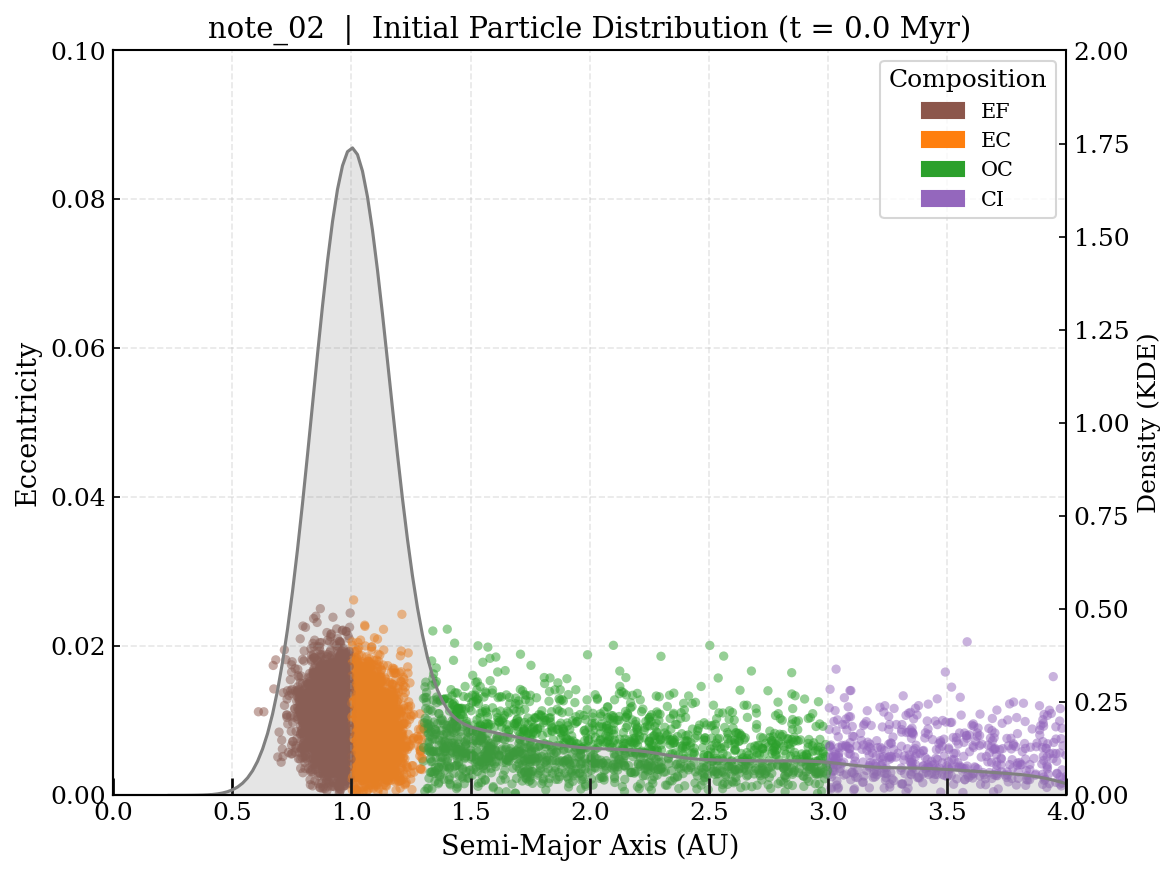

In [4]:
# ============================================================================
# SECTION 2: INITIAL COMPOSITION CLASSIFICATION
# ============================================================================

time_zero = '0.0 Myr'
df_com = A_dict[time_zero][['a', 'e', 'inc', 'm_e']].iloc[2:]  # Exclude giants (i=0,1)

# ── Classify by orbital location ─────────────────────────────────
conditions = [
    (df_com['a'] <= 1.0),
    (df_com['a'] > 1.0) & (df_com['a'] <= 1.3),
    (df_com['a'] > 1.3) & (df_com['a'] <= 3.0),
    (df_com['a'] > 3.0)
]

df_com['com'] = np.select(conditions, composition_types, default=None)
i_com_mapping = dict(zip(df_com.index, df_com['com']))

print(f"Initial particle classification at {time_zero}:")
print(df_com['com'].value_counts().sort_index())
print()

# ── Composition distribution (a-e diagram) ───────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

color_map = {c: Colors[c] for c in composition_types}
colors = df_com['com'].map(color_map)

ax.scatter(df_com['a'], df_com['e'], c=colors, s=20, alpha=0.5, edgecolors='none')

# ── KDE overlay ──────────────────────────────────────────────────
ax2 = ax.twinx()
sns.kdeplot(df_com['a'], ax=ax2, color='gray', linewidth=1.5, fill=True, alpha=0.2)
ax2.set_ylabel('Density (KDE)', fontsize=12)
ax2.set_ylim(0, 2)

# ── Formatting ───────────────────────────────────────────────────
ax.set_xlim(0, 4)
ax.set_ylim(0, 0.1)
ax.set_xlabel('Semi-Major Axis (AU)', fontsize=13)
ax.set_ylabel('Eccentricity', fontsize=13)
ax.set_title(f'{model}  |  Initial Particle Distribution (t = {time_zero})', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, ls='--')

# ── Legend ───────────────────────────────────────────────────────
legend_handles = [mpatches.Patch(color=color_map[c], label=c) for c in composition_types]
ax.legend(handles=legend_handles, title='Composition', loc='upper right', fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

---
## 3. Collision Tracing During Gas Disk Phase (t ≤ 5 Myr)

The gas disk phase (typically 2-5 Myr in planetary formation models) sees intense 
planetesimal collisions. We:

1. Load collision records from the simulation
2. Partition particles into:
   - **Collision particles**: Participated in ≥1 merger event
   - **Original particles**: Preserved from t=0 without collision
3. For collision particles, use `CollisionTracer` to reconstruct their **source composition**  
   by tracing the full merger tree backward to initial planetesimals
4. Compute mixture fractions for each composition endmember (EF/EC/OC/CI)

**Output:** 
- `df_gas_original`: Unmerged particles with pure single-composition assignments
- `df_gas_collision`: Merged particles with mixture fractions [EF, EC, OC, CI]

In [7]:
# ============================================================================
# SECTION 3: COLLISION TRACING (GAS DISK PHASE)
# ============================================================================

# ── Load collision records ───────────────────────────────────────
collision_files = [
    os.path.join(model_path, f) for f in os.listdir(model_path) if f.startswith('Collision')
]
if not collision_files:
    raise FileNotFoundError(f"No Collision file found in {model_path}")

col_names_c = [
    'time',
    'indexi', 'mi', 'ri', 'xi', 'yi', 'zi', 'vxi', 'vyi', 'vzi', 'Sxi', 'Syi', 'Szi',
    'indexj', 'mj', 'rj', 'xj', 'yj', 'zj', 'vxj', 'vyj', 'vzj', 'Sxj', 'Syj', 'Szj',
]

C_data = pd.read_csv(collision_files[0], sep=r'\s+', header=None, names=col_names_c)
C_data['m_ei'] = C_data['mi'] / ad.constants.ME
C_data['m_ej'] = C_data['mj'] / ad.constants.ME

# ── Filter: gas disk phase only (t ≤ 5 Myr) ────────────────────
gas_time_yr = A_dict['5.0 Myr']['t'].iloc[0]
C_withgas = C_data[C_data['time'] <= gas_time_yr].copy()

print(f"Gas disk end time : {gas_time_yr/1e6:.1f} Myr ({gas_time_yr:.2e} yr)")
print(f"Total collisions  : {len(C_data)}")
print(f"Gas disk collisions: {len(C_withgas)}")
print()

# ── Partition particles ──────────────────────────────────────────
C_withgas_id_list1 = C_withgas['indexi'].tolist()
C_withgas_id_list2 = C_withgas['indexj'].tolist()
collision_id_set = set(C_withgas_id_list1) | set(C_withgas_id_list2)
collision_id_list = list(collision_id_set)

time_gas = '5.0 Myr'
df_gas = A_dict[time_gas][['a', 'e', 'inc', 'm_e']].iloc[2:].copy()
gas_index_list = df_gas.index.tolist()

intersection_list = list(set(gas_index_list) & set(collision_id_list))
original_list = list(set(gas_index_list) - set(intersection_list))

print(f"Gas disk snapshot ({time_gas}):")
print(f"  Total particles  : {len(gas_index_list)}")
print(f"  Collision particles: {len(intersection_list)}")
print(f"  Original particles : {len(original_list)}")
print()

# ── Initialize composition columns ───────────────────────────────
for col in composition_types:
    df_gas[col] = np.nan

# ── Original particles: single composition ───────────────────────
df_gas_original = df_gas.loc[original_list].copy()

for idx in df_gas_original.index:
    com_type = df_com.loc[idx, 'com']
    if com_type in composition_types:
        df_gas_original.at[idx, com_type] = df_com.loc[idx, 'm_e']

print(f"Original particles composition assigned ✓")

# ── Collision particles: trace mixture ───────────────────────────
df_c = C_withgas[['time', 'indexi', 'm_ei', 'indexj', 'm_ej']].copy()
tracer = ad.CollisionTracer(df_c)

df_gas_collision = df_gas.loc[intersection_list].copy()

for idx in df_gas_collision.index:
    # Trace full merger history
    h = tracer.trace_full_history(idx)
    index_union = list(set(h['indexi']) | set(h['indexj']))
    
    # Aggregate contributing particles by composition
    union_data = [
        {
            'Index': i,
            'Category': i_com_mapping.get(i, None),
            'm_e': df_com.loc[i, 'm_e'] if i in df_com.index else None
        }
        for i in index_union
    ]
    union_df = pd.DataFrame(union_data)
    category_sums = union_df.groupby('Category')['m_e'].sum()
    
    # Assign mixture fractions
    for com_type in composition_types:
        if com_type in category_sums.index:
            df_gas_collision.at[idx, com_type] = category_sums[com_type]

print(f"Collision particles mixture traced ✓")
print()

Gas disk end time : 4.9 Myr (4.93e+06 yr)
Total collisions  : 5790
Gas disk collisions: 5263

Gas disk snapshot (5.0 Myr):
  Total particles  : 1244
  Collision particles: 341
  Original particles : 903

Original particles composition assigned ✓
Collision particles mixture traced ✓



---
## 4. Compute Embryo Compositions

**Step 4.1:** Load meteorite endmember compositions (normalized to MgO)  
**Step 4.2:** Merge particle data and classify composition mixtures  
**Step 4.3:** Update elemental compositions using `EarlyComUpdater`  
**Step 4.4:** Compute pressure-temperature conditions  
**Step 4.5:** Identify embryos (m ≥ 0.1 M⊕)

In [10]:
# ============================================================================
# SECTION 4: COMPUTE EMBRYO COMPOSITIONS — 修复版本（顺序调整）
# ============================================================================

# ── 4.0 Reset index: preserve particle IDs as column ──────────────
df_gas_all = pd.concat([df_gas_collision, df_gas_original]).sort_values(by='m_e').reset_index()
df_gas_all = df_gas_all.reset_index(drop=True)

print(f"✓ Particle index reset: 'i' preserved as column")
print(f"  df_gas_all shape: {df_gas_all.shape}")
print(f"  Columns (first 5): {df_gas_all.columns.tolist()[:5]}")
print()

# ── 4.1 Load meteorite endmember compositions ────────────────────
mete_file = '../Cosmochemistry/Tables/A2_Meteorites_composition.csv'
if not os.path.exists(mete_file):
    raise FileNotFoundError(f"{mete_file} not found. Run B_Meteorite.ipynb first.")

df_Mete = pd.read_csv(mete_file, index_col=0)

# Normalize to sum=1 per composition
col_sums = df_Mete.sum(numeric_only=True)
df_norm = df_Mete.copy()
safe_sums = col_sums.copy()
safe_sums[safe_sums == 0] = np.nan

num_cols = df_Mete.columns.intersection(col_sums.index)
df_norm[num_cols] = df_Mete[num_cols].div(safe_sums[num_cols], axis=1)

dict_Mete = df_norm.to_dict()

print(f"✓ Loaded meteorite compositions from {mete_file}")
print(f"  Endmembers: {list(dict_Mete.keys())}")
print()

# ── 4.2 Merge collision & original particles ─────────────────────
# Fill NaN with 0 for composition columns
for col in composition_types:
    df_gas_all[col] = df_gas_all[col].fillna(0)

# Compute mixture ratios
total_mass = df_gas_all[composition_types].sum(axis=1)
total_mass = total_mass.replace(0, np.nan)

for col in composition_types:
    df_gas_all[f'{col}_ratio'] = df_gas_all[col] / total_mass

print(f"✓ Merged {len(df_gas_collision)} collision + {len(df_gas_original)} original particles")
print()

# ── 4.3 Compute P-T conditions FIRST ────────────────────────────
# ✅ 关键修复：在调用 EarlyComUpdater 之前先计算 P-T
df_gas_all['P'] = ad.Early_pressure(df_gas_all['m_e'])
df_gas_all['T'] = df_gas_all['P'].apply(ad.P_to_T)

print(f"✓ Pressure-temperature conditions computed")
print(f"  P range: {df_gas_all['P'].min():.2e} - {df_gas_all['P'].max():.2e} Pa")
print(f"  T range: {df_gas_all['T'].min():.0f} - {df_gas_all['T'].max():.0f} K")
print()

# ── 4.4 Update elemental compositions using EarlyComUpdater ───────
# ✅ 现在 df_gas_all 有 'i', 'P', 'T' 列，EarlyComUpdater 可以正常工作
for col in major_items:
    df_gas_all[col] = np.nan

updater = ad.EarlyComUpdater(df_gas_all, dict_Mete, major_items, ad)
updater.batch_update()

print(f"✓ Elemental compositions updated ({len(major_items)} major elements)")
print()

# ── 4.5 Identify embryos (m ≥ 0.1 M⊕) ────────────────────────────
df_embryos = df_gas_all[df_gas_all['m_e'] >= 0.1].sort_values(by='m_e', ascending=False).reset_index(drop=True)

print(f"Embryos identified (m ≥ 0.1 M⊕): {len(df_embryos)}")
print()
print("Embryo summary:")
print(df_embryos[['i', 'm_e', 'a', 'e', 'P', 'T'] + composition_types].head(10).to_string())
print()

✓ Particle index reset: 'i' preserved as column
  df_gas_all shape: (1244, 9)
  Columns (first 5): ['i', 'a', 'e', 'inc', 'm_e']

✓ Loaded meteorite compositions from ../Cosmochemistry/Tables/A2_Meteorites_composition.csv
  Endmembers: ['EF', 'EC', 'OC', 'CI']

✓ Merged 341 collision + 903 original particles

✓ Pressure-temperature conditions computed
  P range: 3.94e-01 - 6.03e+01 Pa
  T range: 1896 - 3568 K

✓ Elemental compositions updated (10 major elements)

Embryos identified (m ≥ 0.1 M⊕): 6

Embryo summary:
      i       m_e         a         e          P            T        EF        EC        OC        CI
0  1123  0.534792  0.737150  0.030149  60.298777  3568.182619  0.262669  0.259380  0.012742  0.000000
1  4189  0.308318  1.028903  0.069765  34.920117  2849.315965  0.113802  0.137479  0.055347  0.001691
2    93  0.292248  0.852052  0.009143  33.119358  2785.885075  0.104263  0.149899  0.037410  0.000677
3  1442  0.256534  0.579128  0.056310  29.117178  2638.218566  0.109186 

---
## 5. Visualization

**5.1:** Linear element composition diagram (X/MgO vs. major elements)  
**5.2:** CI-chondrite-normalized spider diagram (mantle vs. core elements)

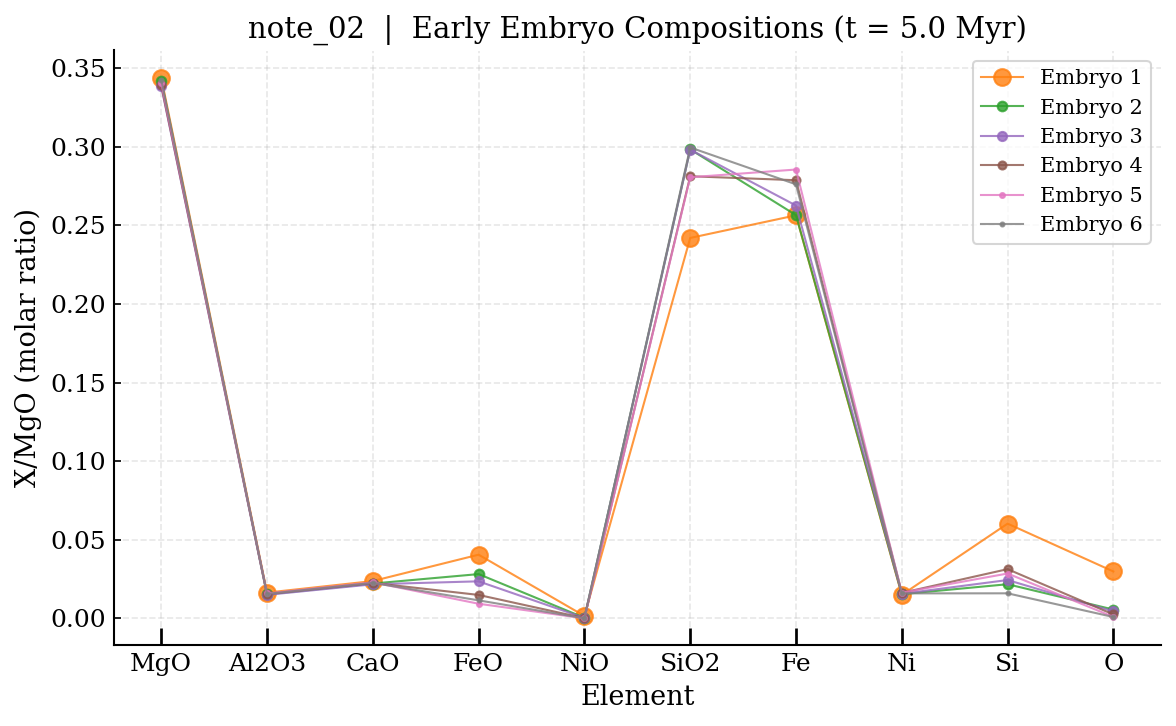

✓ Linear X/MgO diagram plotted


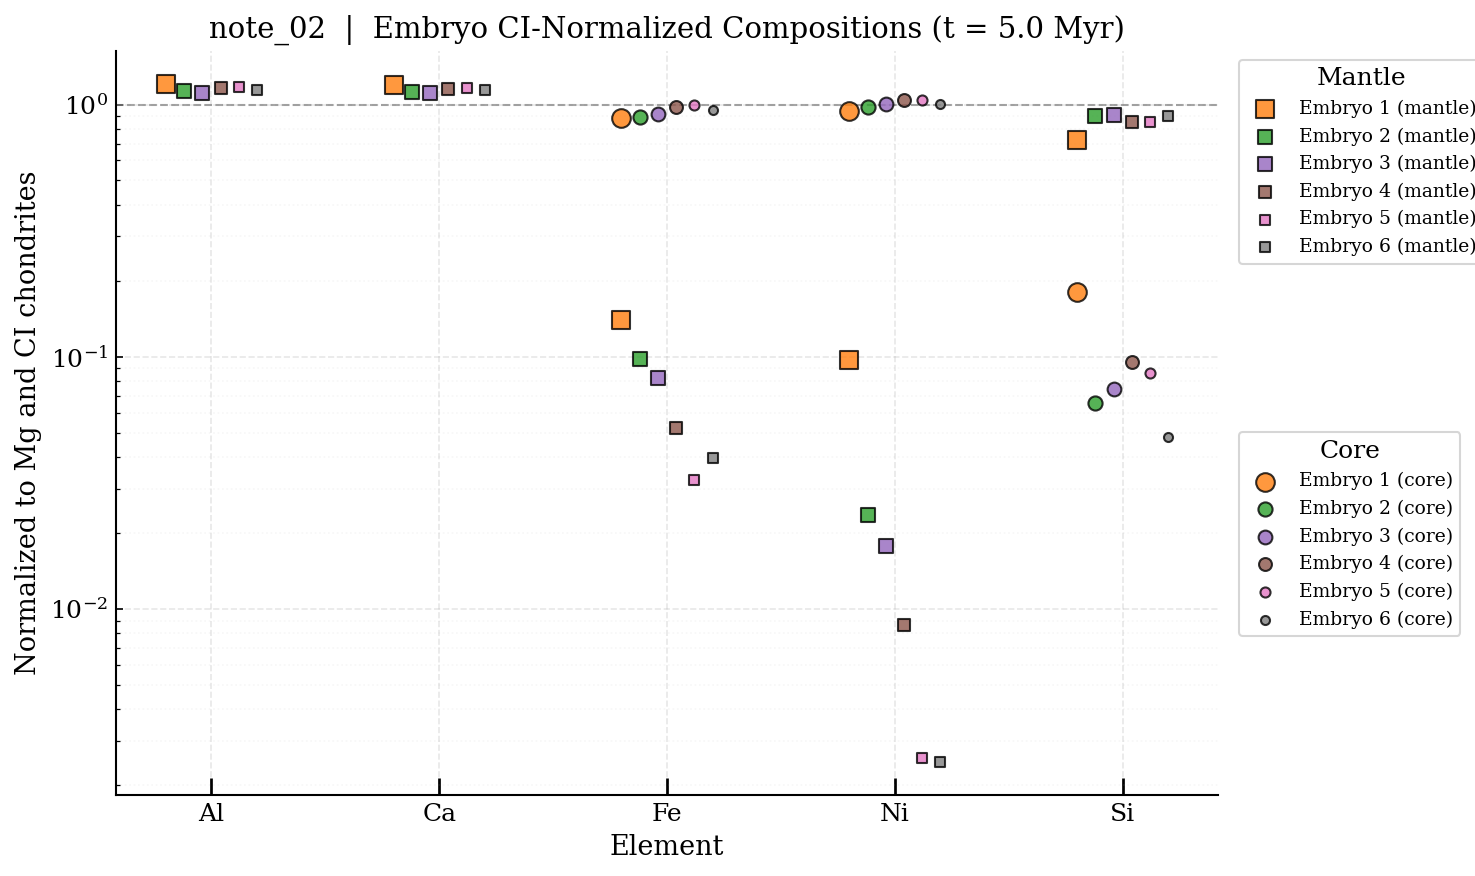

✓ CI-normalized spider diagram plotted



In [11]:
# ============================================================================
# SECTION 5: VISUALIZATION
# ============================================================================

# ── Setup embryo identifiers & colors ────────────────────────────
embryo_ids = [f'Embryo {i+1}' for i in range(len(df_embryos))]
cmap = plt.get_cmap('tab10')
color_indices = [i for i in range(10) if i not in (0, 3)]
embryo_colors = [cmap(color_indices[i % len(color_indices)]) for i in range(len(df_embryos))]

# ── 5.1 Linear X/MgO diagram ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

for i in range(len(df_embryos)):
    x = df_embryos[major_items].iloc[i].index
    y = df_embryos[major_items].iloc[i].values
    m = df_embryos['m_e'].iloc[i]
    
    ax.plot(x, y, marker='o', linewidth=1, markersize=15*m, 
            label=embryo_ids[i], color=embryo_colors[i], alpha=0.8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('X/MgO (molar ratio)', fontsize=13)
ax.set_xlabel('Element', fontsize=13)
ax.set_title(f'{model}  |  Early Embryo Compositions (t = {time_gas})', fontsize=14)
ax.legend(fontsize=10, frameon=True, loc='upper right')
ax.grid(True, alpha=0.3, ls='--')

plt.tight_layout()
plt.show()

print(f"✓ Linear X/MgO diagram plotted")

# ── 5.2 CI-normalized spider diagram ─────────────────────────────
# Normalize to MgO first
df_embryos_Mg = df_embryos[major_items].copy()
df_embryos_Mg = df_embryos_Mg.div(df_embryos['MgO'], axis=0)

# Load CI reference
CI_bulk_mg = ad.constants.CI_bulk_mg
df_CI_bulk_mg = pd.DataFrame([CI_bulk_mg], columns=CI_bulk_mg.keys())

# Normalize to CI
df_embryos_CI = df_embryos_Mg[major_items[1:-1]].copy()
df_embryos_CI[mantle_items[1:]] = df_embryos_CI[mantle_items[1:]].div(
    df_CI_bulk_mg[mantle_items[1:]].values[0]
)
df_embryos_CI[core_items[:-1]] = df_embryos_CI[core_items[:-1]].div(
    df_CI_bulk_mg[mantle_items[3:]].values[0]
)

# ── Setup plot ───────────────────────────────────────────────────
elements = ['Al', 'Ca', 'Fe', 'Ni', 'Si']
mantle_keys = ['Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2']
core_keys = ['Fe', 'Ni', 'Si']

x_idx = np.arange(len(elements))
xx_idx = np.array([2, 3, 4])  # Fe, Ni, Si indices

fig, ax = plt.subplots(figsize=(10, 6))

# Plot each embryo
offsets = np.linspace(-0.2, 0.2, len(df_embryos_CI))

for i in range(len(df_embryos_CI)):
    # Mantle (squares)
    x_mantle = x_idx + offsets[i]
    y_mantle = df_embryos_CI[mantle_keys].iloc[i].values
    ax.scatter(x_mantle, y_mantle, marker='s', s=150*df_embryos['m_e'].iloc[i],
               color=embryo_colors[i], edgecolor='k', alpha=0.8, 
               label=f'{embryo_ids[i]} (mantle)', zorder=3)
    
    # Core (circles)
    x_core = xx_idx + offsets[i]
    y_core = df_embryos_CI[core_keys].iloc[i].values
    ax.scatter(x_core, y_core, marker='o', s=150*df_embryos['m_e'].iloc[i],
               color=embryo_colors[i], edgecolor='k', alpha=0.8,
               label=f'{embryo_ids[i]} (core)', zorder=3)

# Formatting
ax.set_yscale('log')
ax.set_xticks(x_idx)
ax.set_xticklabels(elements, fontsize=12)
ax.set_ylabel('Normalized to Mg and CI chondrites', fontsize=13)
ax.set_xlabel('Element', fontsize=13)
ax.set_title(f'{model}  |  Embryo CI-Normalized Compositions (t = {time_gas})', fontsize=14)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.grid(True, which='major', alpha=0.3, ls='--')
ax.grid(True, which='minor', alpha=0.1, ls=':')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Split legend
handles, labels = ax.get_legend_handles_labels()
mantle_h = [h for h, l in zip(handles, labels) if 'mantle' in l]
mantle_l = [l for l in labels if 'mantle' in l]
core_h = [h for h, l in zip(handles, labels) if 'core' in l]
core_l = [l for l in labels if 'core' in l]

first_leg = ax.legend(mantle_h, mantle_l, title='Mantle',
                      bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=9)
ax.add_artist(first_leg)
ax.legend(core_h, core_l, title='Core',
          bbox_to_anchor=(1.01, 0.5), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print(f"✓ CI-normalized spider diagram plotted")
print()

In [12]:
model

'note_02'

In [14]:
# ============================================================================
# SECTION 6: EXPORT & SUMMARY
# ============================================================================

save_dir = pathlib.Path('./Tables')
save_dir.mkdir(parents=True, exist_ok=True)

# ✅ 修复：使用格式化字符串创建文件名
filename = f'{model}_early_composition.csv'
save_file = save_dir / filename

df_gas_all.to_csv(save_file, index=True)

print(f"✅ Exported: {save_file}")
print(f"  Rows    : {len(df_gas_all)}")
print(f"  Columns : {len(df_gas_all.columns)}")
print()

# Verify
data_verify = pd.read_csv(save_file, index_col=0)
print(f"✓ CSV verification: {len(data_verify)} particles loaded")
print()

# ── Summary statistics ───────────────────────────────────────────
print("=" * 70)
print("WORKFLOW SUMMARY")
print("=" * 70)
print()
print(f"Model                 : {model}")
print(f"Gas disk phase (t≤)   : {time_gas}")
print(f"Total particles @ t=0 : {len(df_com)}")
print()
print(f"@ t = {time_gas}:")
print(f"  Particles alive     : {len(df_gas)}")
print(f"  Collision particles : {len(df_gas_collision)} ({100*len(df_gas_collision)/len(df_gas):.1f}%)")
print(f"  Original particles  : {len(df_gas_original)} ({100*len(df_gas_original)/len(df_gas):.1f}%)")
print()
print(f"Embryos (m ≥ 0.1 M⊕)  : {len(df_embryos)}")
print(f"  Total mass          : {df_embryos['m_e'].sum():.2f} M⊕")
print(f"  Mass range          : {df_embryos['m_e'].min():.3f} - {df_embryos['m_e'].max():.3f} M⊕")
print()
print("Composition distribution (embryos):")
for com_type in composition_types:
    total_com = df_embryos[com_type].sum()
    print(f"  {com_type}: {total_com:.3f} M⊕")
print()
print("Output file:")
print(f"  {save_file}")
print()
print("=" * 70)
print("✅ Workflow complete. Ready for differentiation modeling.")
print("=" * 70)

✅ Exported: Tables/note_02_early_composition.csv
  Rows    : 1244
  Columns : 25

✓ CSV verification: 1244 particles loaded

WORKFLOW SUMMARY

Model                 : note_02
Gas disk phase (t≤)   : 5.0 Myr
Total particles @ t=0 : 7000

@ t = 5.0 Myr:
  Particles alive     : 1244
  Collision particles : 341 (27.4%)
  Original particles  : 903 (72.6%)

Embryos (m ≥ 0.1 M⊕)  : 6
  Total mass          : 1.67 M⊕
  Mass range          : 0.126 - 0.535 M⊕

Composition distribution (embryos):
  EF: 0.710 M⊕
  EC: 0.827 M⊕
  OC: 0.135 M⊕
  CI: 0.002 M⊕

Output file:
  Tables/note_02_early_composition.csv

✅ Workflow complete. Ready for differentiation modeling.
